<div class="output_png output_subarea output_execute_result">
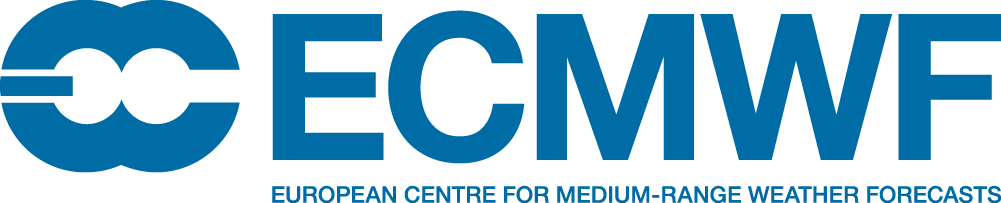
</div>

# 	AIFS ENS Control: Significant wave height of all waves with various periods

This notebook will provide you with guidance on how to explore and plot the ECMWF dataset to produce the map from the ECMWF Open Charts web product.  
The original product can be found at this link: https://charts.ecmwf.int/products/aifs_ens_cf_medium-wave-period


<div class="output_png output_subarea output_execute_result">
<center>
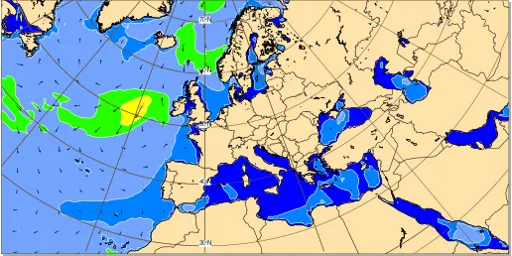</center>
</div>

The full list of available AIFS Open Data products can be found [here](https://www.ecmwf.int/en/forecasts/dataset/aifs-machine-learning-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF AIFS data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain access to the full forecast dataset [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes one of these 6 parameters as input:

* [Significant wave height of all waves with periods within the inclusive range from 10 to 12 seconds](https://codes.ecmwf.int/grib/param-db/140114)
* [Significant wave height of all waves with periods within the inclusive range from 12 to 14 seconds](https://codes.ecmwf.int/grib/param-db/140115)
* [Significant wave height of all waves with periods within the inclusive range from 14 to 17 seconds](https://codes.ecmwf.int/grib/param-db/140116)
* [Significant wave height of all waves with periods within the inclusive range from 17 to 21 seconds](https://codes.ecmwf.int/grib/param-db/140117)
* [Significant wave height of all waves with periods within the inclusive range from 21 to 25 seconds](https://codes.ecmwf.int/grib/param-db/140118)
* [Significant wave height of all waves with periods within the inclusive range from 25 to 30 seconds](https://codes.ecmwf.int/grib/param-db/140119)

In this example, we will use: 
- [**ecmwf-api-client**](https://pypi.org/project/ecmwf-api-client/) to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First, we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on the three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-api-client

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False, model="aifs-ens")

In [3]:
parameters = ["h1012","h1214","h1417","h1721","h2125","h2530"]
filename = "aifs_ens_cf_medium-wave-period.grib"
filename

'aifs_ens_cf_medium-wave-period.grib'

Setting "date" to 0 will download today's data. 
Removing "date" and "time" altogether from the request will download the latest data.  
Try commenting out the date and time to download the latest forecast!

In [4]:
client.retrieve(
    date=0,
    time=0,
    step=12,
    stream="waef",
    type="cf",
    levtype="sfc",
    param=parameters,
    target=filename
)

20260730000000-12h-waef-cf.grib2:   0%|          | 0.00/4.48M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


## Reading and processing the data
Now we can use **Metview's read() function** to read the file.

In [5]:
data = mv.read(filename)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,paramId,class,stream,type,experimentVersionNumber
h1012,surface,0,20260730,0,12,140114,ai,waef,cf,0001
h1214,surface,0,20260730,0,12,140115,ai,waef,cf,0001
h1417,surface,0,20260730,0,12,140116,ai,waef,cf,0001
h1721,surface,0,20260730,0,12,140117,ai,waef,cf,0001
h2125,surface,0,20260730,0,12,140118,ai,waef,cf,0001
h2530,surface,0,20260730,0,12,140119,ai,waef,cf,0001


And an overview of one parameter, where we can see more information, such as units or type of level.

In [7]:
data.describe('h1012')

shortName,h1012
name,Significant wave height of all waves with periods within the inclusive range from 10 to 12 seconds
paramId,140114
units,m
typeOfLevel,surface
level,0
date,20260730
time,0
step,12
class,ai
stream,waef


We can use **ls()** function to list all the fields in the file we downloaded.

In [8]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,gridType
Message,,,,,,,,,
0,ecmf,h1012,surface,0,20260730,0,12,cf,regular_ll
1,ecmf,h1214,surface,0,20260730,0,12,cf,regular_ll
2,ecmf,h1417,surface,0,20260730,0,12,cf,regular_ll
3,ecmf,h1721,surface,0,20260730,0,12,cf,regular_ll
4,ecmf,h2125,surface,0,20260730,0,12,cf,regular_ll
5,ecmf,h2530,surface,0,20260730,0,12,cf,regular_ll


The grib file contains all the parameters, and we will use the **select()** function to filter each one of them.

In [9]:
data_h1012 = data.select(shortName= "h1012")
data_h1214 = data.select(shortName= "h1214")
data_h1417 = data.select(shortName= "h1417")
data_h1721 = data.select(shortName= "h1721")
data_h2125 = data.select(shortName= "h2125")
data_h2530 = data.select(shortName= "h2530")

data_h1012.describe()

parameter,typeOfLevel,level,date,time,step,paramId,class,stream,type,experimentVersionNumber
h1012,surface,0,20260730,0,12,140114,ai,waef,cf,0001


## Plotting the data
And finally, we can plot the data on the map. 

Since several styles are used to plot these parameters, we will plot a few of them.  

First we plot Significant wave height of all waves with periods within the inclusive range from 10 to 12 seconds.  
The same style is for:  
Significant wave height of all waves with periods within the inclusive range from 12 to 14 seconds,  
Significant wave height of all waves with periods within the inclusive range from 14 to 17 seconds and   
Significant wave height of all waves with periods within the inclusive range from 17 to 21 seconds.

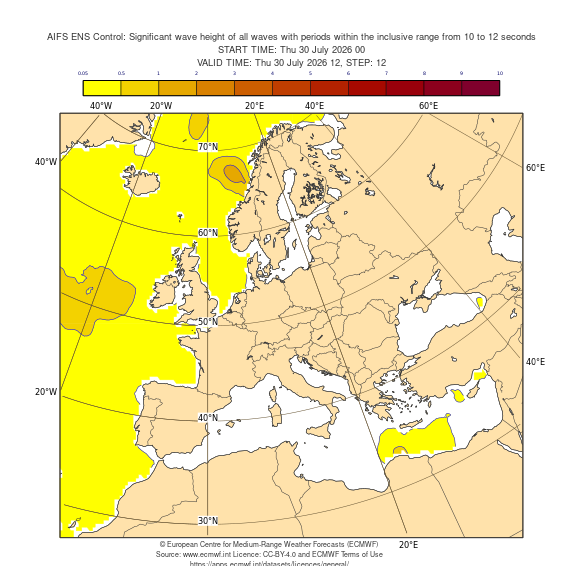

In [10]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
data_h1012_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_wave_f0t10_red")

title = mv.mtext(
    text_lines=["AIFS ENS Control: Significant wave height of all waves with periods within the inclusive range from 10 to 12 seconds",
                "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H' /> ",
                "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H' />, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, data_h1012, data_h1012_shade, title, ecmwf_text)

Next is Significant wave height of all waves with periods within the inclusive range from 21 to 25 seconds.

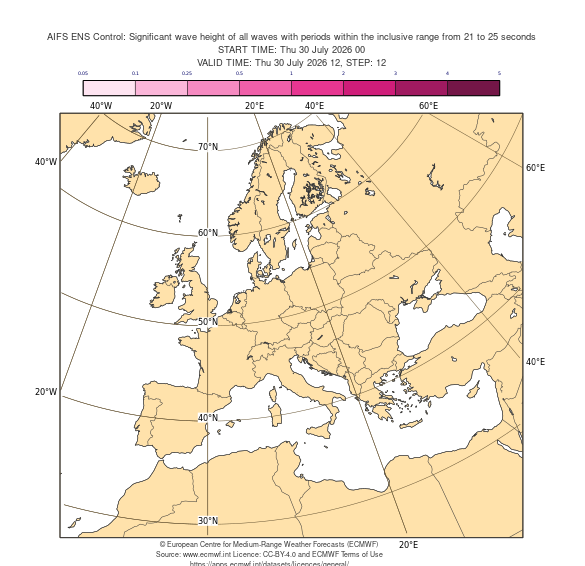

In [11]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
data_h2125_shade = mv.mcont(legend= "on",
    contour_automatics_settings = "style_name",
    contour_style_name = "sh_wave_f005t5_rose")

title = mv.mtext(
    text_lines=["AIFS ENS Control: Significant wave height of all waves with periods within the inclusive range from 21 to 25 seconds", 
                "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
                "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, data_h2125, data_h2125_shade, title, ecmwf_text)

The last one is Significant wave height of all waves with periods within the inclusive range from 25 to 30 seconds.

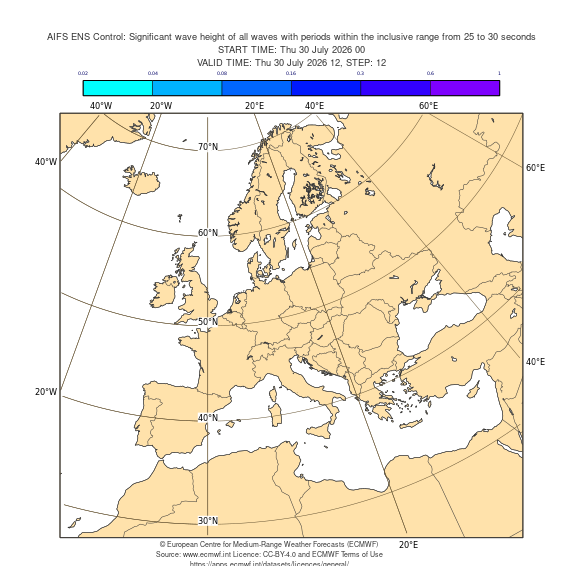

In [12]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
data_h2530_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_wave_f002t1_blue")

title = mv.mtext(
    text_lines=["AIFS ENS Control: Significant wave height of all waves with periods within the inclusive range from 25 to 30 seconds", 
                "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H'/> ",
                "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H'/>, STEP: <grib_info key='step' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, data_h2530, data_h2530_shade, title, ecmwf_text)

To generate the png files you can run the following four cells.

In [14]:
png = mv.png_output(
      output_name = "aifs_ens_cf_medium-wave-period-h1012",   # specify relative or full path
      output_title = "aifs_ens_cf_medium-wave-period-h1012",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, data_h1012, data_h1012_shade, title, ecmwf_text)

In [15]:
png = mv.png_output(
      output_name = "aifs_ens_cf_medium-wave-period-h2125",   # specify relative or full path
      output_title = "aifs_ens_cf_medium-wave-period-h2125",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, data_h2125, data_h2125_shade, title, ecmwf_text)

In [16]:
png = mv.png_output(
      output_name = "aifs_ens_cf_medium-wave-period-h2530",   # specify relative or full path
      output_title = "aifs_ens_cf_medium-wave-period-h2530",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, data_h2530, data_h2530_shade, title, ecmwf_text)

Note that the plot produced using this dataset will slightly differ from the one in Open Charts. This is due to the different resolution of the data.  
We downloaded data on a 0.25x0.25 resolution, while the high-resolution data has a 0.1x0.1 grid.